<a href="https://colab.research.google.com/github/zydanne-costa/Ondas_ADCP_SCO_Mar_Nov_2025/blob/main/Resultados_i_iii.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# 1. Importar bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.stats import pearsonr
import glob
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# 2. Definir diretórios
input_dir = '/content/drive/MyDrive/Ondas/Dados/Refinados/WaveData/'
output_dir = '/content/drive/MyDrive/Ondas/Resultados_dissertacao/'

In [5]:
# 3. Carregar todos os arquivos .txt
files = glob.glob(input_dir + "*.txt")
dataframes = {}
for f in files:
    name = f.split("/")[-1].replace(".txt","")
    df = pd.read_csv(f, sep="\t")
    df['DataHora'] = pd.to_datetime(df['DataHora'])
    dataframes[name] = df

In [6]:
df_chu_1h = dataframes['wwdata_chu']
df_sec_1h = dataframes['wwdata_sec']
df_chu_3h = dataframes['wdata_chu_3H']
df_sec_3h = dataframes['wdata_sec_3H']

In [29]:
# Set global font to serif
plt.rcParams['font.family'] = 'serif'

# Define a custom date formatter for dd/mm/yy
date_formatter = mdates.DateFormatter('%d/%m/%y')

# Formatador para trocar ponto por vírgula e formatar com uma casa decimal
def comma_formatter(x, pos):
    return f"{x:.1f}".replace('.', ',')

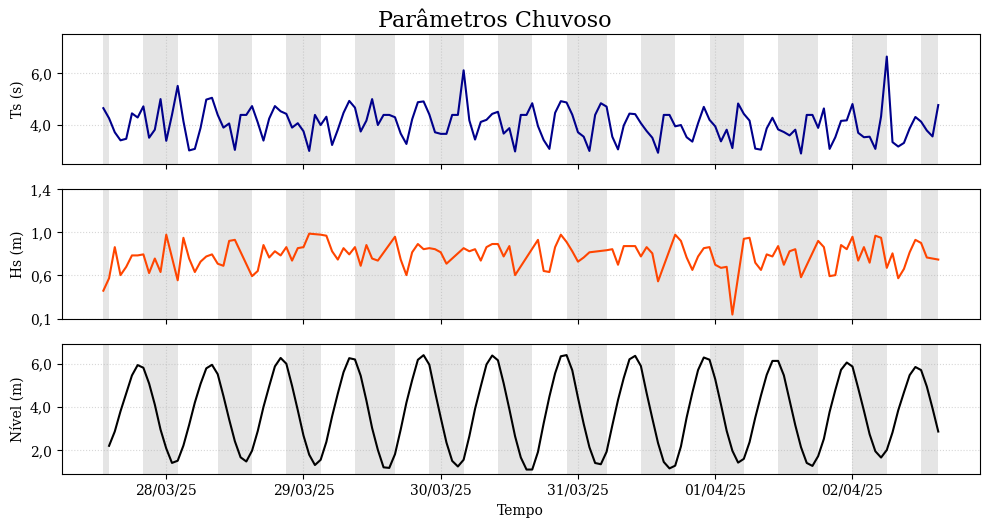

In [83]:
def plot_mare(df, filename):
    # Criando copia para n alterar o original
    df = df.copy()
    # Suaviza a profundidade
    df['Depth_suave'] = (df['Depth_m'].rolling(window=5, center=True, min_periods=1).mean())
    # Classifica a maré usando a profundidade suavizada
    df['Mare'] = df['Depth_suave'].diff().apply(lambda x: 'Enchente' if x > 0 else 'Vazante')

    fig, axs = plt.subplots(3, 1, figsize=(10,5.5), sharex=True)
    fig.suptitle('Parâmetros Chuvoso', fontsize=16, y=0.95) # Add title

    axs[0].plot(df['DataHora'], df['Ts'], color='darkblue')
    axs[0].set_ylabel("Ts (s)")
    axs[0].yaxis.set_major_formatter(ticker.FuncFormatter(comma_formatter))
    axs[0].set_ylim(2.5, 7.5)
    axs[0].set_yticks(np.linspace(4, 6, 2))

    axs[1].plot(df['DataHora'], df['Hs'].replace(0, float('nan')).interpolate(method='linear'), color='orangered')
    axs[1].set_ylabel("Hs (m)")
    axs[1].yaxis.set_major_formatter(ticker.FuncFormatter(comma_formatter))
    axs[1].set_ylim(0.15, 1.4)
    axs[1].set_yticks(np.linspace(0.15, 1.4, 4))

    axs[2].plot(df['DataHora'], df['Depth_m'], color='black')
    axs[2].set_ylabel("Nível (m)")
    axs[2].set_xlabel("Tempo")
    axs[2].yaxis.set_major_formatter(ticker.FuncFormatter(comma_formatter))
    axs[2].set_ylim(0.9, 6.9)

    # Fundo branco/cinza conforme maré
    for ax in axs:
        for i in range(len(df)-1):
            color = 'white' if df['Mare'].iloc[i]=='Enchente' else 'grey'
            ax.axvspan(df['DataHora'].iloc[i], df['DataHora'].iloc[i+1], facecolor=color, alpha=0.2)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%y"))
        ax.tick_params(axis='x', rotation=0)
        ax.grid(True, linestyle=':', alpha=0.5, which='major', axis='y') # horizontal
        ax.grid(True, linestyle=':', alpha=0.5, which='major', axis='x') # vertical

    plt.tight_layout()
    plt.savefig(output_dir + filename + "_mare.png")
    #plt.close()

plot_mare(df_chu_1h, "chu_1h")

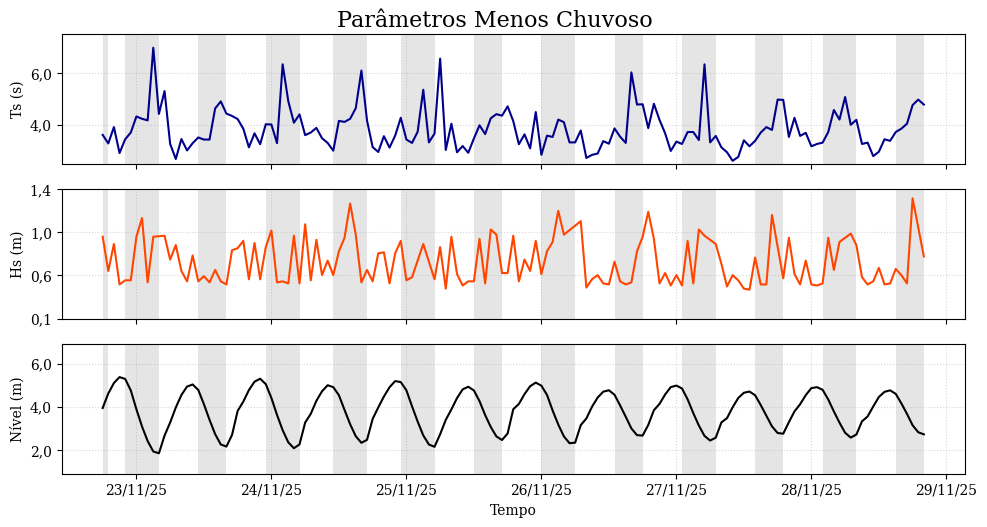

In [84]:
def plot_mare(df, filename):
    # Criando copia para n alterar o original
    df = df.copy()
    # Suaviza a profundidade
    df['Depth_suave'] = (df['Depth_m'].rolling(window=5, center=True, min_periods=1).mean())
    # Classifica a maré usando a profundidade suavizada
    df['Mare'] = df['Depth_suave'].diff().apply(lambda x: 'Enchente' if x > 0 else 'Vazante')

    fig, axs = plt.subplots(3, 1, figsize=(10,5.5), sharex=True)
    fig.suptitle('Parâmetros Menos Chuvoso', fontsize=16, y=0.95)

    axs[0].plot(df['DataHora'], df['Ts'], color='darkblue')
    axs[0].set_ylabel("Ts (s)")
    axs[0].yaxis.set_major_formatter(ticker.FuncFormatter(comma_formatter))
    axs[0].set_ylim(2.5, 7.5)
    axs[0].set_yticks(np.linspace(4, 6, 2))

    axs[1].plot(df['DataHora'], df['Hs'].replace(0, float('nan')).interpolate(method='linear'), color='orangered')
    axs[1].set_ylabel("Hs (m)")
    axs[1].yaxis.set_major_formatter(ticker.FuncFormatter(comma_formatter))
    axs[1].set_ylim(0.15, 1.4)
    axs[1].set_yticks(np.linspace(0.15, 1.4, 4))

    axs[2].plot(df['DataHora'], df['Depth_m'], color='black')
    axs[2].set_ylabel("Nível (m)")
    axs[2].set_xlabel("Tempo")
    axs[2].yaxis.set_major_formatter(ticker.FuncFormatter(comma_formatter))
    axs[2].set_ylim(0.9, 6.9)

    # Fundo branco/cinza conforme maré
    for ax in axs:
        for i in range(len(df)-1):
            color = 'white' if df['Mare'].iloc[i]=='Enchente' else 'grey'
            ax.axvspan(df['DataHora'].iloc[i], df['DataHora'].iloc[i+1], facecolor=color, alpha=0.2)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%y"))
        ax.tick_params(axis='x', rotation=0)
        ax.grid(True, linestyle=':', alpha=0.5, which='major', axis='y') # horizontal grid
        ax.grid(True, linestyle=':', alpha=0.5, which='major', axis='x') # vertical grid

    plt.tight_layout()
    plt.savefig(output_dir + filename + "_mare.png")
    #plt.close()

plot_mare(df_sec_1h, "sec_1h")

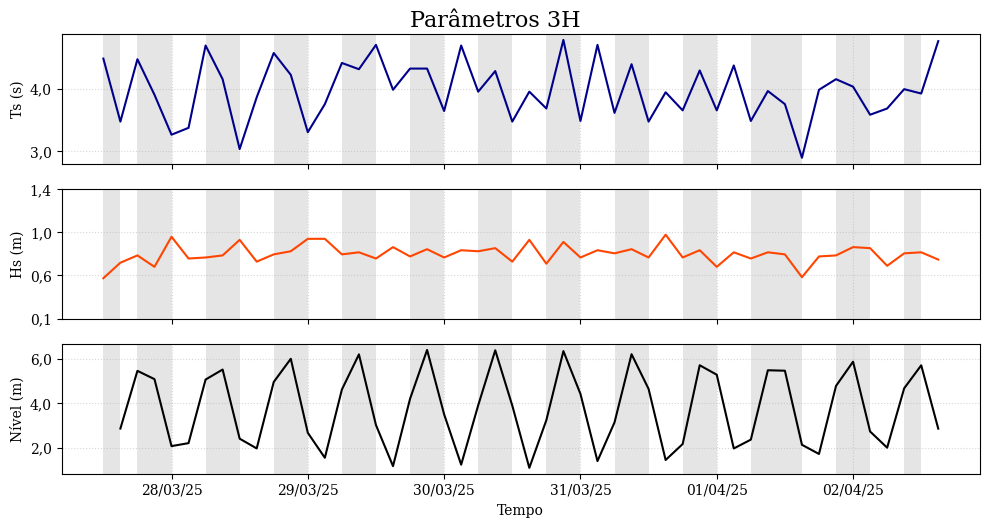

In [78]:
def plot_mare(df, filename):
    # Criando copia para n alterar o original
    df = df.copy()
    # Suaviza a profundidade
    df['Depth_suave'] = (df['Depth_m'].rolling(window=5, center=True, min_periods=1).mean())
    # Classifica a maré usando a profundidade suavizada
    df['Mare'] = df['Depth_suave'].diff().apply(lambda x: 'Enchente' if x > 0 else 'Vazante')

    fig, axs = plt.subplots(3, 1, figsize=(10,5.5), sharex=True)
    fig.suptitle('Parâmetros 3H', fontsize=16, y=0.95) # Add title

    axs[0].plot(df['DataHora'], df['Ts'], color='darkblue')
    axs[0].set_ylabel("Ts (s)")
    axs[0].yaxis.set_major_formatter(ticker.FuncFormatter(comma_formatter))

    axs[1].plot(df['DataHora'], df['Hs'].replace(0, float('nan')).interpolate(method='linear'), color='orangered')
    axs[1].set_ylabel("Hs (m)")
    axs[1].yaxis.set_major_formatter(ticker.FuncFormatter(comma_formatter))
    axs[1].set_ylim(0.15, 1.4)
    axs[1].set_yticks(np.linspace(0.15, 1.4, 4))

    axs[2].plot(df['DataHora'], df['Depth_m'], color='black')
    axs[2].set_ylabel("Nível (m)")
    axs[2].set_xlabel("Tempo")
    axs[2].yaxis.set_major_formatter(ticker.FuncFormatter(comma_formatter))

    # Fundo branco/cinza conforme maré
    for ax in axs:
        for i in range(len(df)-1):
            color = 'white' if df['Mare'].iloc[i]=='Enchente' else 'grey'
            ax.axvspan(df['DataHora'].iloc[i], df['DataHora'].iloc[i+1], facecolor=color, alpha=0.2)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%y"))
        ax.tick_params(axis='x', rotation=0)
        ax.grid(True, linestyle=':', alpha=0.5, which='major', axis='y') # Add horizontal grid
        ax.grid(True, linestyle=':', alpha=0.5, which='major', axis='x') # Add vertical grid

    plt.tight_layout()
    plt.savefig(output_dir + filename + "_mare.png")
    plt.close()

plot_mare(df_chu_3h, "chu_3h")